In [1]:
!pip install transformer-lens transformers accelerate  circuitsvis


  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of torch to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.5/7.5 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 821.0/821.0 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 393.1/393.1 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 116.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.7/897.7 kB 67.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.0/571.0 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
import json
from transformer_lens import loading_from_pretrained as loading
from transformer_lens import  HookedTransformer
import transformer_lens.utilities as utils
from transformer_lens.hook_points import HookPoint
from transformers import AutoTokenizer


import torch.nn.functional as F
import torch
import torch.optim as optim
from sklearn.model_selection import train_test_split
import torch.nn as nn
import einops
import seaborn as sns
from itertools import product
import itertools
import random
import numpy as np
import matplotlib.pyplot as plt
import circuitsvis as cv
import plotly.graph_objects as go
import plotly.io as pio
from IPython.display import display, HTML
from sklearn.decomposition import FastICA
import graphviz
import networkx as nx





In [3]:
from transformer_lens import loading_from_pretrained as loading

# This dictionaries hold all the shorthand aliases mapped to Hugging Face paths
print("Official Short Aliases:")
for alias in loading.MODEL_ALIASES.keys():
    print(f" - {alias}")

print("\nOfficial Checkpoint Collections:")
for official_model in loading.OFFICIAL_MODEL_NAMES:
    print(f" - {official_model}")

Official Short Aliases:
 - 01-ai/Yi-34B
 - 01-ai/Yi-34B-Chat
 - 01-ai/Yi-6B
 - 01-ai/Yi-6B-Chat
 - ai-forever/mGPT
 - allenai/OLMo-1B-hf
 - allenai/OLMo-2-0425-1B
 - allenai/OLMo-2-1124-7B
 - allenai/Olmo-3-32B-Think
 - allenai/Olmo-3-7B-Instruct
 - allenai/Olmo-3-7B-Think
 - allenai/Olmo-3.1-32B-Instruct
 - allenai/Olmo-3.1-32B-Think
 - allenai/OLMo-7B-hf
 - allenai/OLMoE-1B-7B-0924
 - ArthurConmy/redwood_attn_2l
 - Baidicoot/Othello-GPT-Transformer-Lens
 - bigcode/santacoder
 - bigscience/bloom-1b1
 - bigscience/bloom-1b7
 - bigscience/bloom-3b
 - bigscience/bloom-560m
 - bigscience/bloom-7b1
 - codellama/CodeLlama-7b-hf
 - codellama/CodeLlama-7b-Instruct-hf
 - codellama/CodeLlama-7b-Python-hf
 - distilgpt2
 - EleutherAI/gpt-j-6B
 - EleutherAI/gpt-neo-1.3B
 - EleutherAI/gpt-neo-125M
 - EleutherAI/gpt-neo-2.7B
 - EleutherAI/gpt-neox-20b
 - EleutherAI/pythia-1.4b
 - EleutherAI/pythia-1.4b-deduped
 - EleutherAI/pythia-1.4b-deduped-v0
 - EleutherAI/pythia-1.4b-v0
 - EleutherAI/pythia-12b

In [4]:
# 1. Switch to the Instruct variant!
model_id = "gpt2-medium"

tokenizer = AutoTokenizer.from_pretrained(model_id)

config.json:   0%|          | 0.00/718 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

In [5]:
model = HookedTransformer.from_pretrained_no_processing(
    model_id,
    device="cuda",
    dtype=torch.float16,
    tokenizer=tokenizer, # Pass the pre-initialized tokenizer to avoid re-loading issues
    default_prepend_bos=False # Explicitly disable prepending BOS token by HookedTransformer
)

model.safetensors:   0%|          | 0.00/1.52G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Loaded pretrained model gpt2-medium into HookedTransformer


In [6]:
def get_device():
    if torch.cuda.is_available():
        return "cuda"
    elif torch.backends.mps.is_available():
        return "mps"
    else:
        return "cpu"

device = get_device()
print(f"Using {device} device")

Using cuda device


In [7]:
def get_loss(mat, components, sparsity='l1'):
  # Ensure mat is on the same device as reconstructed for calculations
  mat_on_device = mat.to(device) # Moved this up for consistent device usage

  # matrix reconstruction loss
  comp_list = []
  n_components = len(components)
  reconstructed = torch.zeros_like(mat_on_device, device=device) # Use mat_on_device for zeros_like reference
  for U,S,V in components:
    #S = S.reshape(1)
    S = F.softplus(S)
    Mi = U @ torch.diag(S) @ (V.T)
    comp_list.append(Mi)
    reconstructed += Mi

  reconstruction_error = ((mat_on_device-reconstructed)**2).mean()

  # Matrix Cosine Similarity Loss
  mat_flat = mat_on_device.flatten()
  reconstructed_flat = reconstructed.flatten()
  matrix_cosine_sim = F.cosine_similarity(mat_flat, reconstructed_flat, dim=0)
  matrix_cosine_loss = (1 - matrix_cosine_sim) # We want to maximize similarity, so minimize (1 - sim)

  #column space orthogonality
  loss_col = torch.tensor(0.0, device=device)
  for i in range(n_components):
        U_i, _, _ = components[i]
        U_i_norm, _ = torch.linalg.qr(U_i.to(torch.float32))
        for j in range(i + 1, n_components):
            U_j, _, _ = components[j]
            U_j_norm, _ = torch.linalg.qr(U_j.to(torch.float32))
            overlap = U_i_norm.T @ U_j_norm
            rank_i = U_i_norm.shape[1]
            rank_j = U_j_norm.shape[1]
            norm_factor = torch.sqrt(torch.tensor(rank_i * rank_j, device=device, dtype=torch.float32))
            loss_col += (torch.norm(overlap, p="fro") / norm_factor)

  loss_row = torch.tensor(0.0,device=device)
  for i in range(n_components):
            _, _, V_i = components[i]
            V_i_norm, _ = torch.linalg.qr(V_i)
            for j in range(i + 1, n_components):
                _, _, V_j = components[j]
                V_j_norm, _ = torch.linalg.qr(V_j)
                overlap = V_i_norm.T @ V_j_norm
                rank_i = V_i_norm.shape[1]
                rank_j = V_j_norm.shape[1]
                norm_factor = torch.sqrt(torch.tensor(rank_i * rank_j,device=device,dtype=torch.float32))
                loss_row += (torch.norm(overlap, p="fro")/ norm_factor)

  if n_components > 1:
        n_pairs = n_components * (n_components - 1) / 2
        loss_col /= n_pairs
        loss_row /= n_pairs

  # Combined loss with new cosine similarity terms
  total_loss = 5*reconstruction_error + 5*loss_col + 3*loss_row + 0.5*matrix_cosine_loss
  return total_loss

In [8]:
def train(mat, n_components=16, n_iterations=65, rank=4):
    d_out, d_in = mat.shape
    components = []
    params = []

    for _ in range(n_components):
        # Create directly on the device to keep them as leaf nodes
        U = torch.empty(d_out, rank, device=device)
        torch.nn.init.xavier_normal_(U)
        U.requires_grad_(True)

        V = torch.empty(d_in, rank, device=device)
        torch.nn.init.xavier_normal_(V)
        V.requires_grad_(True)

        S = torch.ones(rank, device=device, requires_grad=True)

        components.append((U, S, V))
        params.extend([U, S, V])

    optimizer = torch.optim.Adam(params, lr=1e-2)

    # ... rest of your loop

    # --- Scheduler Setup ---
    # mode='min' because we want to reduce LR when loss stops decreasing
    # factor=0.5 means new_lr = lr * 0.5
    # patience=5 means wait 5 epochs of no improvement before dropping LR
    '''scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2   )'''

    for epoch in range(n_iterations):
        optimizer.zero_grad()
        loss = get_loss(mat, components)
        loss.backward()
        optimizer.step()

        # --- Update Scheduler ---
        #scheduler.step(loss)

        print(f"Epoch: {epoch+1}, Loss: {loss.item():.6f}, LR: {optimizer.param_groups[0]['lr']:.6f}")

    return components

In [9]:
layer = 5
head = 0
q_matrix_layer_5 = model.blocks[layer].attn.W_Q
print(f"Shape of Layer 5 Q Matrix: {q_matrix_layer_5.shape}")

Shape of Layer 5 Q Matrix: torch.Size([16, 1024, 64])


In [10]:
w_q_layer_5 = model.blocks[5].attn.W_Q
first_head_q = w_q_layer_5[head, :, :].to(torch.float32).T

In [11]:
n_components = 16
d_in = 1024
d_out =64
factor = 1
rank = max(1, min(d_in, d_out) // n_components*factor)
components = train(first_head_q,n_components=n_components,rank = rank)

Epoch: 1, Loss: 1.331969, LR: 0.010000
Epoch: 2, Loss: 1.156080, LR: 0.010000
Epoch: 3, Loss: 1.053249, LR: 0.010000
Epoch: 4, Loss: 0.937453, LR: 0.010000
Epoch: 5, Loss: 0.840494, LR: 0.010000
Epoch: 6, Loss: 0.761229, LR: 0.010000
Epoch: 7, Loss: 0.690537, LR: 0.010000
Epoch: 8, Loss: 0.632377, LR: 0.010000
Epoch: 9, Loss: 0.584744, LR: 0.010000
Epoch: 10, Loss: 0.539905, LR: 0.010000
Epoch: 11, Loss: 0.502483, LR: 0.010000
Epoch: 12, Loss: 0.472655, LR: 0.010000
Epoch: 13, Loss: 0.445110, LR: 0.010000
Epoch: 14, Loss: 0.419462, LR: 0.010000
Epoch: 15, Loss: 0.395683, LR: 0.010000
Epoch: 16, Loss: 0.374239, LR: 0.010000
Epoch: 17, Loss: 0.355177, LR: 0.010000
Epoch: 18, Loss: 0.335959, LR: 0.010000
Epoch: 19, Loss: 0.316904, LR: 0.010000
Epoch: 20, Loss: 0.299354, LR: 0.010000
Epoch: 21, Loss: 0.283358, LR: 0.010000
Epoch: 22, Loss: 0.268104, LR: 0.010000
Epoch: 23, Loss: 0.253295, LR: 0.010000
Epoch: 24, Loss: 0.239227, LR: 0.010000
Epoch: 25, Loss: 0.225748, LR: 0.010000
Epoch: 26

In [12]:
comp_list = []
for U,S,V in components:
  #S = S.reshape(1)
  S = F.softplus(S)
  Mi = U @ torch.diag(S) @ (V.T)
  comp_list.append(Mi)


In [13]:
Wq_reconstructed = torch.stack(comp_list).sum(0)

In [14]:
from torch.nn.functional import cosine_similarity
def get_matrix_reconstruction_metrics(original_weights,comp_list):
  # Get the original weights and the reconstructed matrix
  original_weights = original_weights.detach().cpu()
  reconstructed_matrix = torch.stack(comp_list, dim=0).sum(dim=0).detach().cpu()

  # Flatten both matrices to 1D vectors for cosine similarity calculation
  original_weights_flat = original_weights.flatten()
  reconstructed_matrix_flat = reconstructed_matrix.flatten()

  # Calculate cosine similarity
  similarity_metric = cosine_similarity(original_weights_flat, reconstructed_matrix_flat, dim=0)

  reconstruction_error = ((original_weights - reconstructed_matrix)**2).mean()
  print(f"Reconstruction MSE: {reconstruction_error.item():.6f}")
  print(f"Cosine Similarity between original and reconstructed weights: {similarity_metric.item():.6f}")
  return reconstruction_error, similarity_metric
_,_ = get_matrix_reconstruction_metrics(first_head_q,comp_list)


Reconstruction MSE: 0.001226
Cosine Similarity between original and reconstructed weights: 0.964247


In [15]:
import torch
import statistics

def get_orthogonality_metrics(components):
    # --- Helper for processing overlaps ---
    def process_overlaps(bases):
        all_overlaps = []
        num_bases = len(bases)

        for i in range(num_bases):
            Bi = bases[i]
            rank_i = Bi.shape[1]
            for j in range(i + 1, num_bases):
                Bj = bases[j]
                rank_j = Bj.shape[1]

                overlap = Bi.T @ Bj
                fro_norm = torch.norm(overlap, p='fro')
                norm_factor = torch.sqrt(torch.tensor(rank_i * rank_j, dtype=torch.float32))
                normalized_fro_norm = (fro_norm / norm_factor).item()

                all_overlaps.append(normalized_fro_norm)
                print(f"  Overlap between Component {i+1} and Component {j+1}: {normalized_fro_norm:.6f}")

        avg = statistics.mean(all_overlaps) if all_overlaps else 0.0
        med = statistics.median(all_overlaps) if all_overlaps else 0.0
        return avg, med

    # --- Process Column Space (U) ---
    print("Normalized Frobenius Norm of Overlap for Column Space (U):\n")
    U_bases = [torch.linalg.qr(c[0].to(torch.float32))[0].cpu().detach() for c in components]
    col_avg, col_med = process_overlaps(U_bases)
    print(f"-> Column Space | Avg: {col_avg:.6f}, Median: {col_med:.6f}")

    # --- Process Row Space (V) ---
    print("\nNormalized Frobenius Norm of Overlap for Row Space (V):\n")
    V_bases = [torch.linalg.qr(c[2].to(torch.float32))[0].cpu().detach() for c in components]
    row_avg, row_med = process_overlaps(V_bases)
    print(f"-> Row Space    | Avg: {row_avg:.6f}, Median: {row_med:.6f}")

    return col_avg,col_med,row_avg,row_med
_,_,_,_ = get_orthogonality_metrics(components)

Normalized Frobenius Norm of Overlap for Column Space (U):

  Overlap between Component 1 and Component 2: 0.001060
  Overlap between Component 1 and Component 3: 0.000851
  Overlap between Component 1 and Component 4: 0.002220
  Overlap between Component 1 and Component 5: 0.002292
  Overlap between Component 1 and Component 6: 0.000605
  Overlap between Component 1 and Component 7: 0.002141
  Overlap between Component 1 and Component 8: 0.000886
  Overlap between Component 1 and Component 9: 0.001296
  Overlap between Component 1 and Component 10: 0.000753
  Overlap between Component 1 and Component 11: 0.000637
  Overlap between Component 1 and Component 12: 0.002042
  Overlap between Component 1 and Component 13: 0.001172
  Overlap between Component 1 and Component 14: 0.001483
  Overlap between Component 1 and Component 15: 0.000668
  Overlap between Component 1 and Component 16: 0.000622
  Overlap between Component 2 and Component 3: 0.000815
  Overlap between Component 2 and Com

In [16]:
prompts = [

# Arithmetic
"What is 17 + 28?",
"Calculate 145 - 87.",
"What is 12 times 13?",
"What is 144 divided by 12?",
"What is 25 squared?",
"What is 7 * 8 + 15?",
"What is 100 minus 73?",
"What is 19 + 45?",
"What is 3 cubed?",
"What is 81 divided by 9?",

# General knowledge
"What is the capital of France?",
"What is the largest planet?",
"Who wrote Hamlet?",
"What is the chemical symbol for gold?",
"What is the tallest mountain on Earth?",
"What is the currency of Japan?",
"What is the fastest land animal?",
"Who discovered penicillin?",
"What is the largest ocean?",
"What is the boiling point of water?",

# Science
"Explain photosynthesis briefly.",
"What causes gravity?",
"What is DNA?",
"What is an atom?",
"What is the speed of light?",
"What is a black hole?",
"What is a neuron?",
"What is evolution?",
"What is entropy?",
"What is quantum mechanics?",

# Stories
"Once upon a time there was a dragon",
"A detective entered the abandoned mansion",
"The spaceship landed on Mars",
"A young girl found a mysterious key",
"The king received a strange letter",
"A robot woke up in an empty city",
"A pirate discovered a hidden map",
"The magician opened an ancient book",
"A scientist built a time machine",
"The wolf stared at the moon",

# Reasoning
"If all cats are animals and Tom is a cat, what is Tom?",
"If John is taller than Mike and Mike is taller than Sam, who is tallest?",
"What comes next: 2,4,6,8?",
"If a train travels 60 km in 1 hour, how far in 3 hours?",
"What is the opposite of hot?",
"If today is Monday, what day comes after Wednesday?",
"What color do you get by mixing red and blue?",
"If 5 apples cost 10 dollars, how much does 1 apple cost?",
"What is half of 100?",
"What is bigger, 1/2 or 1/4?",

# Coding
"Write a Python function to add two numbers.",
"What does a for loop do in Python?",
"Explain recursion.",
"What is a dictionary in Python?",
"What is a list comprehension?",
"How do you open a file in Python?",
"What is an array?",
"What is a variable?",
"What is a function?",
"What is object oriented programming?",

# Commonsense
"Why do people wear coats in winter?",
"Why do birds fly?",
"Why do plants need sunlight?",
"Why do humans sleep?",
"Why is water important?",
"Why do cars need fuel?",
"Why do we brush our teeth?",
"Why does ice melt?",
"Why do people exercise?",
"Why do we need food?",

# Continuation
"The capital city of Germany is",
"The largest mammal in the world is",
"The president walked into the room and",
"The weather today is",
"The scientist discovered that",
"The dog chased the",
"The recipe begins with",
"The movie ended when",
"The teacher explained that",
"The book was about",

# Multi-step arithmetic
"What is (12+8)*3?",
"What is 50-(12+8)?",
"What is (7*9)-20?",
"What is 120/(5*2)?",
"What is 13*11?",
"What is 250+175?",
"What is 999-123?",
"What is 14 squared?",
"What is 72/8?",
"What is 5*5*5?",

# Misc
"Describe a beautiful sunset.",
"Explain the internet.",
"What is artificial intelligence?",
"Tell me a joke.",
"Describe a cat.",
"Describe a forest.",
"Explain democracy.",
"What is music?",
"What is friendship?",
"Describe the ocean."
]

In [17]:
activation_mse = []
activation_cos = []

for prompt in prompts:

    cache = {}

    def save_q(act, hook):
        cache["orig"] = act.detach()

    model.run_with_hooks(
        prompt,
        fwd_hooks=[
            (f"blocks.{layer}.attn.hook_q", save_q)
        ]
    )

    orig = cache["orig"]

    cache2 = {}

    def save_q_recon(act, hook):
        cache2["recon"] = act.detach()

    model.run_with_hooks(
        prompt,
        fwd_hooks=[
            (
                f"blocks.{layer}.attn.hook_q",
                lambda act, hook: save_q_recon(act, hook)
            )
        ]
    )

    recon = cache2["recon"]

    mse = F.mse_loss(recon, orig)

    cos = F.cosine_similarity(
        orig.reshape(-1),
        recon.reshape(-1),
        dim=0
    )

    activation_mse.append(mse.item())
    activation_cos.append(cos.item())

## 5. More Informative Metrics

Beyond the matrix-level `activation_mse` / `cosine_similarity` and the orthogonality metrics above, we evaluate the *downstream* effect of swapping the low-rank reconstruction of `head`'s `W_Q` into a real forward pass, and how much each individual component contributes to that head's activations.

**Logit-level metrics** (does the reconstruction change what the model actually predicts?):
- `KL(p_original || p_reconstructed)` between final-token logits
- `logit_mse`
- top-1 agreement
- top-5 agreement (is the original model's top token still inside the reconstruction's top-5?)

**Per-component metrics** (which components matter, and how much do they overlap?):
- `h_i = x @ M_i.T`, `norm_i = h_i.norm(dim=-1).mean()`
- cosine similarity of each component's contribution against the ground-truth Q activation and against the full reconstruction

### 5.1 Patch the reconstructed head into a real forward pass

In [18]:
def run_with_reconstructed_head(prompt, layer, head, Wq_recon):
    """
    Run the model on `prompt`, but replace the Q projection of `head` at `layer`
    with the low-rank reconstruction `Wq_recon` (same shape as `Mi` / `first_head_q`,
    i.e. [d_head, d_model]).

    We re-derive Q for that head as  x @ Wq_recon.T + b_Q[head] , where `x` is the
    actual normalized residual stream that fed the *real* attention layer on this
    forward pass (captured via a hook). The original bias is kept so that only the
    *weight* reconstruction error propagates downstream -- everything else in the
    model (all other heads, all other layers) is untouched.

    Returns the full logits tensor [batch, pos, d_vocab].
    """
    cache = {}

    def save_x(act, hook):
        cache["x"] = act.detach()
        return act

    def patch_q(act, hook):
        x = cache["x"]                                              # [batch, pos, d_model]
        Wq = Wq_recon.to(act.dtype).to(act.device)                  # [d_head, d_model]
        b_q_head = model.blocks[layer].attn.b_Q[head].to(act.dtype) # [d_head]
        recon_q_head = x.to(act.dtype) @ Wq.T + b_q_head            # [batch, pos, d_head]
        act = act.clone()
        act[:, :, head, :] = recon_q_head
        return act

    logits = model.run_with_hooks(
        prompt,
        fwd_hooks=[
            (f"blocks.{layer}.ln1.hook_normalized", save_x),
            (f"blocks.{layer}.attn.hook_q", patch_q),
        ],
    )
    return logits

### 5.2 KL divergence, logit MSE, top-1 / top-5 agreement

In [19]:
TOP_K = 5  # "top-5 agreement" checks whether the original model's top-1 token
           # is still inside the reconstructed model's top-K predictions.

logit_mse_list = []
kl_list = []
top1_agreement_list = []
top5_agreement_list = []

for prompt in prompts:

    # --- Original (clean) forward pass ---
    orig_logits = model(prompt)                 # [1, pos, d_vocab]
    orig_last = orig_logits[0, -1, :].float()

    # --- Forward pass with the reconstructed head substituted in ---
    recon_logits = run_with_reconstructed_head(prompt, layer, head, Wq_reconstructed)
    recon_last = recon_logits[0, -1, :].float()

    # logit MSE
    logit_mse_list.append(F.mse_loss(recon_last, orig_last).item())

    # KL(p_original || p_reconstructed)
    log_p_orig = F.log_softmax(orig_last, dim=-1)
    p_orig = log_p_orig.exp()
    log_p_recon = F.log_softmax(recon_last, dim=-1)
    kl = F.kl_div(log_p_recon, p_orig, reduction="sum")
    kl_list.append(kl.item())

    # top-1 / top-K agreement
    top1_orig = orig_last.argmax().item()
    top1_recon = recon_last.argmax().item()
    topk_recon = recon_last.topk(TOP_K).indices.tolist()

    top1_agreement_list.append(int(top1_orig == top1_recon))
    top5_agreement_list.append(int(top1_orig in topk_recon))

logit_mse = sum(logit_mse_list) / len(logit_mse_list)
kl_divergence = sum(kl_list) / len(kl_list)
top1_agreement = sum(top1_agreement_list) / len(top1_agreement_list)
top5_agreement = sum(top5_agreement_list) / len(top5_agreement_list)

print(f"Evaluated on {len(prompts)} prompts (layer {layer}, head {head})\n")
print(f"Logit MSE:                         {logit_mse:.6f}")
print(f"KL(p_original || p_reconstructed):  {kl_divergence:.6f}")
print(f"Top-1 agreement:                    {top1_agreement:.2%}")
print(f"Top-{TOP_K} agreement:                    {top5_agreement:.2%}")

Evaluated on 100 prompts (layer 5, head 0)

Logit MSE:                         0.236975
KL(p_original || p_reconstructed):  0.000328
Top-1 agreement:                    100.00%
Top-5 agreement:                    100.00%


### 5.3 Per-component activation norm & cosine similarity contribution

In [20]:
# Collect the normalized residual stream `x` (the input to W_Q) and the
# ground-truth per-head Q activation (`h_target`), pooled across every token
# in the prompt set, so the per-component stats below are computed over a
# reasonably large sample rather than a single prompt.

xs = []
h_targets = []

for prompt in prompts:
    cache = {}

    def save_x(act, hook):
        cache["x"] = act.detach()

    def save_q(act, hook):
        cache["q"] = act.detach()

    model.run_with_hooks(
        prompt,
        fwd_hooks=[
            (f"blocks.{layer}.ln1.hook_normalized", save_x),
            (f"blocks.{layer}.attn.hook_q", save_q),
        ],
    )

    x = cache["x"][0].float()                  # [pos, d_model]
    q_head = cache["q"][0, :, head, :].float()  # [pos, d_head]  -- ground-truth target

    xs.append(x)
    h_targets.append(q_head)

x_all = torch.cat(xs, dim=0).to(device)             # [total_tokens, d_model]
h_target_all = torch.cat(h_targets, dim=0).to(device)  # [total_tokens, d_head]

print(f"Collected activations for {x_all.shape[0]} tokens across {len(prompts)} prompts.")

Collected activations for 658 tokens across 100 prompts.


In [21]:
def get_component_activation_contributions(comp_list, x_all, h_target_all):
    """
    For each component M_i, computes:
      h_i      = x @ M_i.T                                (per-token activation contribution)
      norm_i   = h_i.norm(dim=-1).mean()                   (average magnitude of that contribution)
      cos_target_i = cosine_similarity(h_i, h_target)      (alignment with the real, ground-truth Q activation)
      cos_total_i  = cosine_similarity(h_i, h_recon_total) (alignment with the full reconstruction, i.e.
                                                              how much this component overlaps with the
                                                              combined output of all components)
    """
    h_list = []
    for Mi in comp_list:
        Mi = Mi.to(x_all.device).float()
        h_i = x_all @ Mi.T  # [total_tokens, d_head]
        h_list.append(h_i)

    h_recon_total = torch.stack(h_list, dim=0).sum(dim=0)  # [total_tokens, d_head]

    norms, cos_targets, cos_totals = [], [], []
    for h_i in h_list:
        norms.append(h_i.norm(dim=-1).mean().item())
        cos_targets.append(F.cosine_similarity(h_i, h_target_all, dim=-1).mean().item())
        cos_totals.append(F.cosine_similarity(h_i, h_recon_total, dim=-1).mean().item())

    return norms, cos_targets, cos_totals


component_norms, component_cos_target, component_cos_total = get_component_activation_contributions(
    comp_list, x_all, h_target_all
)

total_norm = sum(component_norms)

print(f"{'Component':>10} | {'norm_i':>10} | {'% of total':>11} | {'cos vs target':>14} | {'cos vs total recon':>19}")
print("-" * 75)
for i, (n, ct, cr) in enumerate(zip(component_norms, component_cos_target, component_cos_total)):
    pct = 100 * n / total_norm
    print(f"{i:>10} | {n:>10.4f} | {pct:>10.2f}% | {ct:>14.4f} | {cr:>19.4f}")

 Component |     norm_i |  % of total |  cos vs target |  cos vs total recon
---------------------------------------------------------------------------
         0 |    17.1650 |       7.32% |         0.2005 |              0.2806
         1 |    13.4713 |       5.74% |         0.1459 |              0.2183
         2 |    13.6340 |       5.81% |         0.2746 |              0.2223
         3 |     9.1282 |       3.89% |         0.1237 |              0.1482
         4 |    12.7944 |       5.46% |         0.1747 |              0.2092
         5 |    19.8945 |       8.48% |         0.1610 |              0.3255
         6 |    16.4669 |       7.02% |         0.2040 |              0.2668
         7 |    11.0258 |       4.70% |         0.1738 |              0.1801
         8 |    12.8822 |       5.49% |         0.1072 |              0.2091
         9 |    15.2428 |       6.50% |         0.1829 |              0.2487
        10 |    11.3943 |       4.86% |         0.1708 |              0.1915


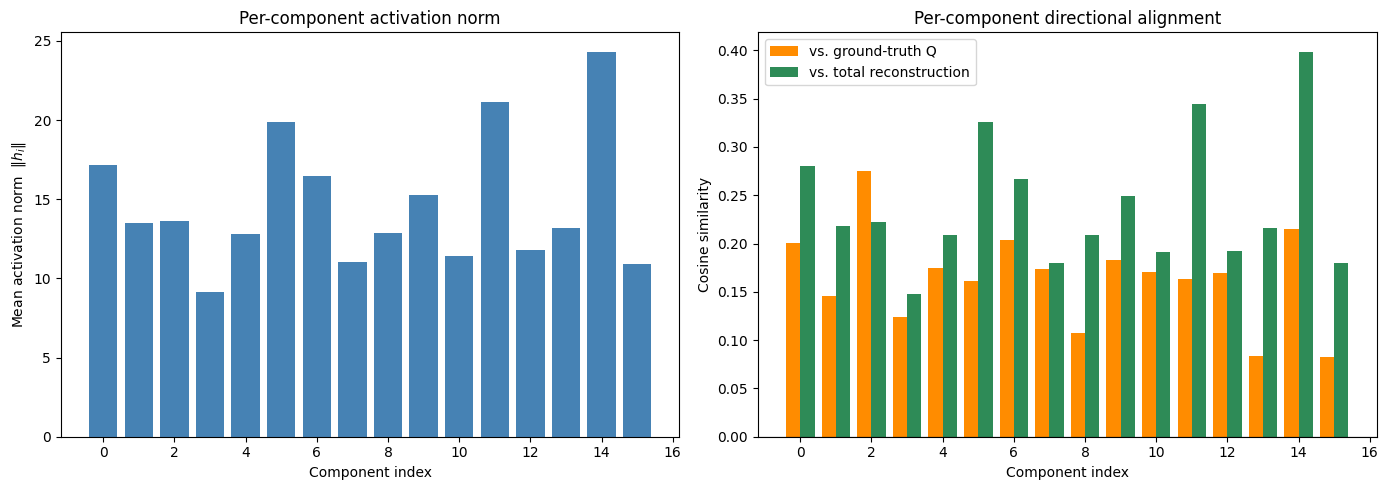

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(len(component_norms)), component_norms, color="steelblue")
axes[0].set_xlabel("Component index")
axes[0].set_ylabel(r"Mean activation norm  $\|h_i\|$")
axes[0].set_title("Per-component activation norm")

x_pos = range(len(component_cos_target))
width = 0.4
axes[1].bar([p - width / 2 for p in x_pos], component_cos_target, width=width,
            color="darkorange", label="vs. ground-truth Q")
axes[1].bar([p + width / 2 for p in x_pos], component_cos_total, width=width,
            color="seagreen", label="vs. total reconstruction")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Component index")
axes[1].set_ylabel("Cosine similarity")
axes[1].set_title("Per-component directional alignment")
axes[1].legend()

plt.tight_layout()
plt.show()